# Catalogue Dataset Preprocessing

## Library Imports

In [1]:
# ============================================================================
# LIBRARY IMPORTS
# Import all necessary packages for data manipulation, visualization,
# API requests, and statistical analysis.
# ============================================================================

# To handle dataframe objects
import pandas as pd

# To create temporary csv files for inspection
import tempfile

# To handle api requests and responses
import requests

# To add delay in the api requests (avoid rate limiting)
import time

# To provide type hints for function parameters and returns
from typing import Dict, Optional

# To visualize data and create plots
import matplotlib.pyplot as plt

# To suppress warnings during execution
import warnings

# To perform probability distribution fitting and numerical operations
import numpy as np
import scipy.stats as stats
from scipy.optimize import minimize
from scipy.special import gammaln, beta as beta_func

In [64]:
# Suppress all warnings while executing the code to keep output clean
warnings.filterwarnings('ignore')

## Helper Functions

### Utility Functions

In [65]:
# ============================================================================
# UTILITY FUNCTIONS
# Helper functions for displaying missing value summaries and exporting data.
# ============================================================================

def MissingValueSummary(df):
    """
    Display a summary of missing values in a DataFrame.
    
    Shows the total number of instances and a table with:
    - Column names
    - Count of missing values per column
    - Percentage of missing values per column
    
    Args:
        df: pandas DataFrame to analyze
    """
    print(f'Number of instances = {df.shape[0]}')
    print('\nMissing Values Summary:')
    print('=' * 50)

    # Create summary DataFrame with missing value statistics
    missing_data = pd.DataFrame({
        'Column': df.columns,
        'Missing_Values': [df[col].isnull().sum() for col in df.columns],
        'Percent_Missing': [(df[col].isnull().sum() / len(df)) * 100 for col in df.columns]
    })

    # Print formatted table
    print(missing_data.to_string(index=False, formatters={'Percent_Missing': '{:.2f}%'.format}))

In [66]:
def TempCSVFile(df):
    """
    Export DataFrame to a temporary CSV file for inspection.
    
    Creates a temporary file that persists after closing (delete=False)
    and prints the file path for manual inspection.
    
    Args:
        df: pandas DataFrame to export
    """
    temp_csv = tempfile.NamedTemporaryFile(mode='w', suffix='.csv', delete=False)
    df.to_csv(temp_csv.name, index=False)
    temp_csv.close()
    print(f"Data exported to: {temp_csv.name}")

### API Functions

In [67]:
# ============================================================================
# API FUNCTIONS
# Functions to fetch book metadata (ISBN, title, author) from external APIs.
# Uses Open Library and Google Books APIs with fallback logic.
# ============================================================================

def fetch_isbn_from_title_author(title: str, author: str) -> Optional[str]:
    """
    Fetch ISBN from external APIs using book title and author.
    
    Tries Open Library API first, then falls back to Google Books API.
    
    Args:
        title: Book title string
        author: Author name string
    
    Returns:
        ISBN string if found, None otherwise
    """
    try:
        # Clean and validate inputs
        clean_title = str(title).strip() if pd.notna(title) else ""
        clean_author = str(author).strip() if pd.notna(author) else ""
        
        if not clean_title:
            return None
        
        # Build Open Library API query
        query_parts = []
        if clean_title:
            query_parts.append(f"title:{clean_title}")
        if clean_author:
            query_parts.append(f"author:{clean_author}")
        
        query = " ".join(query_parts)
        url = f"https://openlibrary.org/search.json?q={requests.utils.quote(query)}&limit=3"
        response = requests.get(url, timeout=10)
        
        # Parse Open Library response
        if response.status_code == 200:
            data = response.json()
            if data.get('numFound', 0) > 0:
                for doc in data.get('docs', []):
                    isbn_list = doc.get('isbn', [])
                    if isbn_list:
                        return isbn_list[0]
        
        # Fallback to Google Books API
        google_query = f"{clean_title} {clean_author}".strip()
        google_url = f"https://www.googleapis.com/books/v1/volumes?q={requests.utils.quote(google_query)}"
        google_response = requests.get(google_url, timeout=10)
        
        if google_response.status_code == 200:
            google_data = google_response.json()
            if google_data.get('totalItems', 0) > 0:
                identifiers = google_data['items'][0]['volumeInfo'].get('industryIdentifiers', [])
                for identifier in identifiers:
                    if identifier.get('type') in ['ISBN_13', 'ISBN_10']:
                        return identifier.get('identifier')
                
    except Exception as e:
        print(f"Error fetching ISBN: {e}")
    
    return None

In [68]:
def fill_missing_isbns(df: pd.DataFrame) -> tuple:
    """
    Fill missing ISBN/ISSN values using Title and Author lookup.
    
    Iterates through rows with missing ISBN but having Title and Author,
    attempts to fetch ISBN from external APIs.
    
    Args:
        df: DataFrame with ISBN/ISSN, Title, and Author columns
    
    Returns:
        Tuple of (updated_dataframe, rows_that_were_processed)
    """
    df_filled = df.copy()
    
    # Identify rows needing ISBN lookup
    mask = df_filled['ISBN/ISSN'].isna() & df_filled['Title'].notna() & df_filled['Author'].notna()
    rows_to_process = df_filled[mask]
    
    print(f"🔍 Found {len(rows_to_process)} rows with missing ISBN but having Title and Author")
    print("=" * 60)
    
    if len(rows_to_process) == 0:
        print("✅ No rows need ISBN lookup")
        return df_filled, pd.DataFrame()
    
    processed, found_isbns = 0, 0
    
    for idx, row in rows_to_process.iterrows():
        print(f"Processing row {idx}:")
        print(f"  Title:  {row['Title'][:60]}...")
        print(f"  Author: {row['Author'][:40]}...")
        
        # Fetch ISBN from APIs
        isbn = fetch_isbn_from_title_author(row['Title'], row['Author'])
        
        if isbn:
            df_filled.at[idx, 'ISBN/ISSN'] = isbn
            found_isbns += 1
            print(f"  ✅ Found ISBN: {isbn}")
        else:
            print(f"  ❌ No ISBN found")
        
        processed += 1
        
        # Rate limiting delay
        if processed < len(rows_to_process):
            time.sleep(0.5)
        
        # Progress update every 5 rows
        if processed % 5 == 0:
            print(f"Progress: {processed}/{len(rows_to_process)}")
    
    # Print summary
    print("=" * 60)
    print(f"📊 RESULTS:")
    print(f"  Rows processed: {processed}")
    print(f"  ISBNs found: {found_isbns}")
    print(f"  Success rate: {found_isbns/max(processed,1)*100:.1f}%")
    
    return df_filled, rows_to_process

In [69]:
def fetch_book_metadata_by_isbn(isbn: str) -> Optional[Dict]:
    """
    Fetch book title and author from APIs using ISBN.
    
    Tries Open Library API first, then falls back to Google Books API.
    Skips ISBNs marked as 'UNKNOWN'.
    
    Args:
        isbn: ISBN string to look up
    
    Returns:
        Dict with 'title' and 'author' keys if found, None otherwise
    """
    try:
        # Skip placeholder ISBNs
        if str(isbn).strip().upper() == 'UNKNOWN':
            return None
            
        # Try Open Library API
        url = f"https://openlibrary.org/api/books?bibkeys=ISBN:{isbn}&format=json&jscmd=data"
        response = requests.get(url, timeout=10)
        
        if response.status_code == 200:
            data = response.json()
            book_key = f"ISBN:{isbn}"
            
            if book_key in data:
                book_data = data[book_key]
                authors = book_data.get('authors', [])
                return {
                    'title': book_data.get('title', ''),
                    'author': authors[0].get('name', '') if authors else ''
                }
        
        # Fallback to Google Books API
        google_url = f"https://www.googleapis.com/books/v1/volumes?q=isbn:{isbn}"
        google_response = requests.get(google_url, timeout=10)
        
        if google_response.status_code == 200:
            google_data = google_response.json()
            if google_data.get('totalItems', 0) > 0:
                item = google_data['items'][0]['volumeInfo']
                authors = item.get('authors', [])
                return {
                    'title': item.get('title', ''),
                    'author': authors[0] if authors else ''
                }
                
    except Exception as e:
        print(f"Error fetching metadata for ISBN {isbn}: {e}")
    
    return None

In [70]:
def update_all_titles_authors(df: pd.DataFrame) -> pd.DataFrame:
    """
    Update Title and Author columns using ISBN API lookup.
    
    Fetches metadata for each row with a valid ISBN and updates
    missing or different values. Converts all results to UPPERCASE.
    
    Args:
        df: DataFrame with ISBN/ISSN, Title, and Author columns
    
    Returns:
        Updated DataFrame with enriched title/author data
    """
    df_updated = df.copy()
    
    print(f"📚 Processing {len(df_updated)} rows...")
    print("=" * 60)
    
    processed, updated_titles, updated_authors, skipped_unknown = 0, 0, 0, 0
    
    for idx, row in df_updated.iterrows():
        isbn = str(row['ISBN/ISSN']).strip() if pd.notna(row['ISBN/ISSN']) else ''
        
        # Skip 'UNKNOWN' or empty ISBNs
        if isbn.upper() == 'UNKNOWN':
            skipped_unknown += 1
            continue
        if not isbn:
            continue
        
        # Fetch metadata from APIs
        metadata = fetch_book_metadata_by_isbn(isbn)
        
        if metadata:
            # Update Title if we got a new one
            new_title = metadata.get('title', '').upper() if metadata.get('title') else ''
            if new_title and (pd.isna(row['Title']) or str(row['Title']).strip() != new_title):
                df_updated.at[idx, 'Title'] = new_title
                updated_titles += 1
            
            # Update Author if we got a new one
            new_author = metadata.get('author', '').upper() if metadata.get('author') else ''
            if new_author and (pd.isna(row['Author']) or str(row['Author']).strip() != new_author):
                df_updated.at[idx, 'Author'] = new_author
                updated_authors += 1
        
        processed += 1
        
        # Progress update every 10 rows
        if processed % 10 == 0:
            print(f"Processed {processed}/{len(df_updated)} rows...")
        
        # Rate limiting delay
        time.sleep(0.3)
    
    # Print summary
    print("=" * 60)
    print(f"📊 UPDATE SUMMARY:")
    print(f"  Total rows processed: {processed}")
    print(f"  Rows with ISBN='UNKNOWN' skipped: {skipped_unknown}")
    print(f"  Titles updated: {updated_titles}")
    print(f"  Authors updated: {updated_authors}")
    
    # Convert ALL titles and authors to uppercase (including existing ones)
    df_updated['Title'] = df_updated['Title'].apply(lambda x: str(x).upper() if pd.notna(x) else x)
    df_updated['Author'] = df_updated['Author'].apply(lambda x: str(x).upper() if pd.notna(x) else x)
    
    print(f"  All titles/authors converted to UPPERCASE")
    
    return df_updated

### Visualisation Function

In [71]:
# ============================================================================
# VISUALIZATION FUNCTION
# Function to create pie and bar charts for analyzing column value distributions.
# ============================================================================

def visualize_unique_values(df, column_name, max_categories=10, figsize=(12, 8)):
    """
    Create visualizations for unique values in a column.
    
    Generates a pie chart showing distribution and a horizontal bar chart
    showing top values. Groups small categories as "Other" when needed.
    
    Args:
        df: DataFrame to analyze
        column_name: Column to visualize
        max_categories: Maximum categories to show individually in pie chart
        figsize: Figure size tuple (width, height)
    
    Returns:
        Series with value counts for further analysis
    """
    # Get value counts and total
    value_counts = df[column_name].value_counts(dropna=False)
    total = len(df)
    
    # Replace NaN with "Missing" for display
    value_counts_display = value_counts.copy()
    value_counts_display.index = value_counts_display.index.fillna('Missing')
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(f'Analysis of "{column_name}" Column', fontsize=16, fontweight='bold')
    
    # --- PIE CHART (Left) ---
    ax1 = axes[0]
    
    # Group small categories as "Other" if too many
    if len(value_counts) > max_categories:
        main_categories = value_counts_display.head(max_categories - 1)
        other_sum = value_counts_display.tail(len(value_counts) - (max_categories - 1)).sum()
        pie_data = pd.concat([main_categories, pd.Series({'Other': other_sum})])
        pie_labels = pie_data.index.tolist()
        pie_values = pie_data.values
        
        # Create explode effect for "Other"
        explode = [0.05] * len(pie_labels)
        if 'Other' in pie_labels:
            explode[pie_labels.index('Other')] = 0.1
    else:
        pie_labels = value_counts_display.index.tolist()
        pie_values = value_counts_display.values
        explode = [0.05] * len(pie_labels)
    
    # Create pie chart
    wedges, texts, autotexts = ax1.pie(
        pie_values, labels=pie_labels, autopct='%1.1f%%',
        startangle=90, explode=explode, shadow=True, textprops={'fontsize': 10}
    )
    
    # Improve autopct text styling
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    ax1.set_title(f'Distribution of {column_name}\n({total} total items)', fontsize=12, fontweight='bold')
    ax1.axis('equal')
    
    # --- BAR CHART (Right) ---
    ax2 = axes[1]
    
    # Show top categories in bar chart
    top_n = min(15, len(value_counts_display))
    top_values = value_counts_display.head(top_n)
    
    bars = ax2.barh(range(len(top_values)), top_values.values)
    ax2.set_yticks(range(len(top_values)))
    ax2.set_yticklabels(top_values.index)
    ax2.invert_yaxis()
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax2.text(width + (width * 0.01), bar.get_y() + bar.get_height()/2,
                f'{width:,} ({width/total*100:.1f}%)', va='center', fontsize=9, fontweight='bold')
    
    ax2.set_xlabel('Number of Items')
    ax2.set_title(f'Top {top_n} Values in {column_name}', fontsize=12, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    return value_counts

## First Glance At The Catalogue

In [74]:
# ============================================================================
# DATA LOADING
# Load the raw library catalogue dataset and set column names.
# ============================================================================

# Retrieve the dataset from the csv file
raw_library_catalogue = pd.read_csv('../../data/raw/csv/library catalogue.csv', header='infer', na_values=None)

# Apply the respective columns to the dataframe
raw_library_catalogue.columns = ['ISBN/ISSN','Title','Author','Side','Copy Count']

# Display basic info about the dataset
print(f'Number of instances = {raw_library_catalogue.shape[0]}')
print(f'Number of attributes = {raw_library_catalogue.shape[1]}')
raw_library_catalogue.head()

Number of instances = 620
Number of attributes = 5


,ISBN/ISSN,Title,Author,Side,Copy Count
0,978996101320,Calcul DIfferentiel et Integral Tome 01,"Piskounov,N",515.33/PIS/1,6.0
1,9782744070372,"Compilateurs : principes, techniques et outils...","Aho, Alfred",004.4 AHO/1,2.0
2,2729823212,"Bit après bit : numération, arithmétique binai...","Mercier, Jean-Jacques",513.52 MER/1,1.0
3,274640432X,"Le Nouveau guide du PC : comprendre, acheter, ...","Steiner, Jack",004 STE/1,1.0
4,2704200106,Introduction à l'informatique : cours et probl...,"Scheid, Francis",004 SCH,1.0


### Setting The Datatypes

In [75]:
# Display the current data types of each column
raw_library_catalogue.dtypes

ISBN/ISSN      object
Title          object
Author         object
Side           object
Copy Count    float64
dtype: object

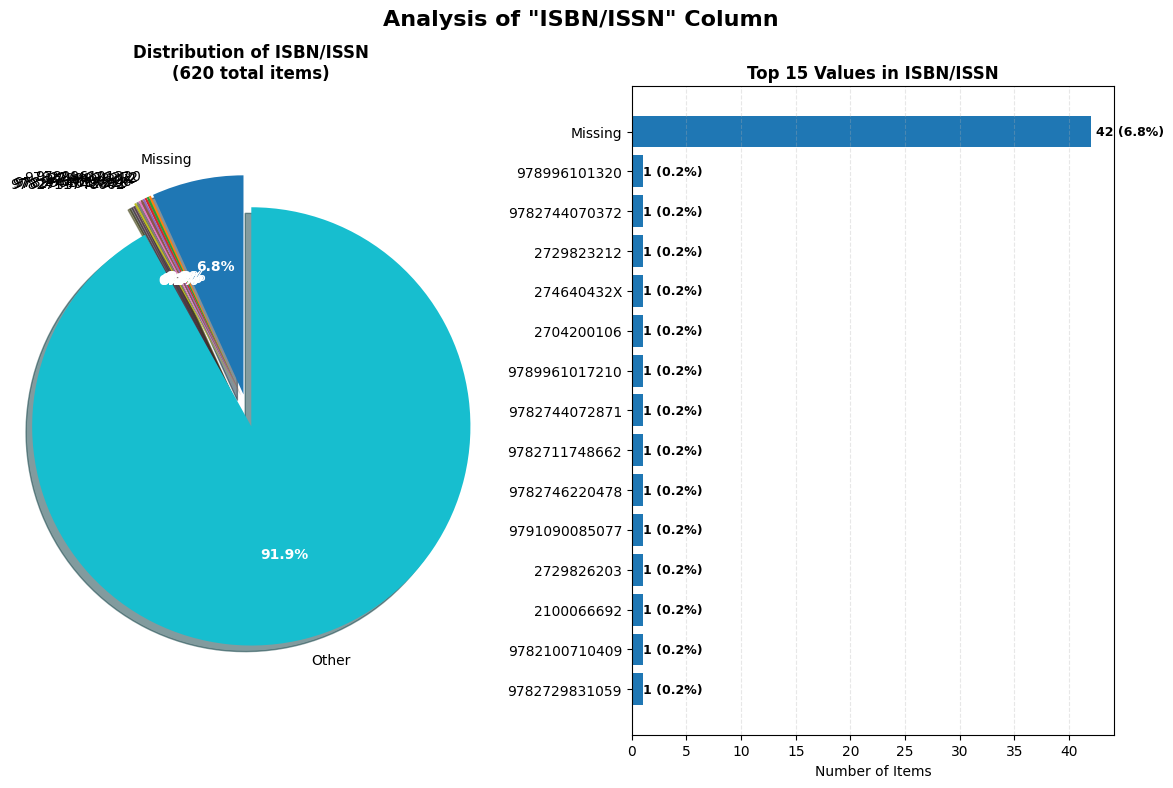

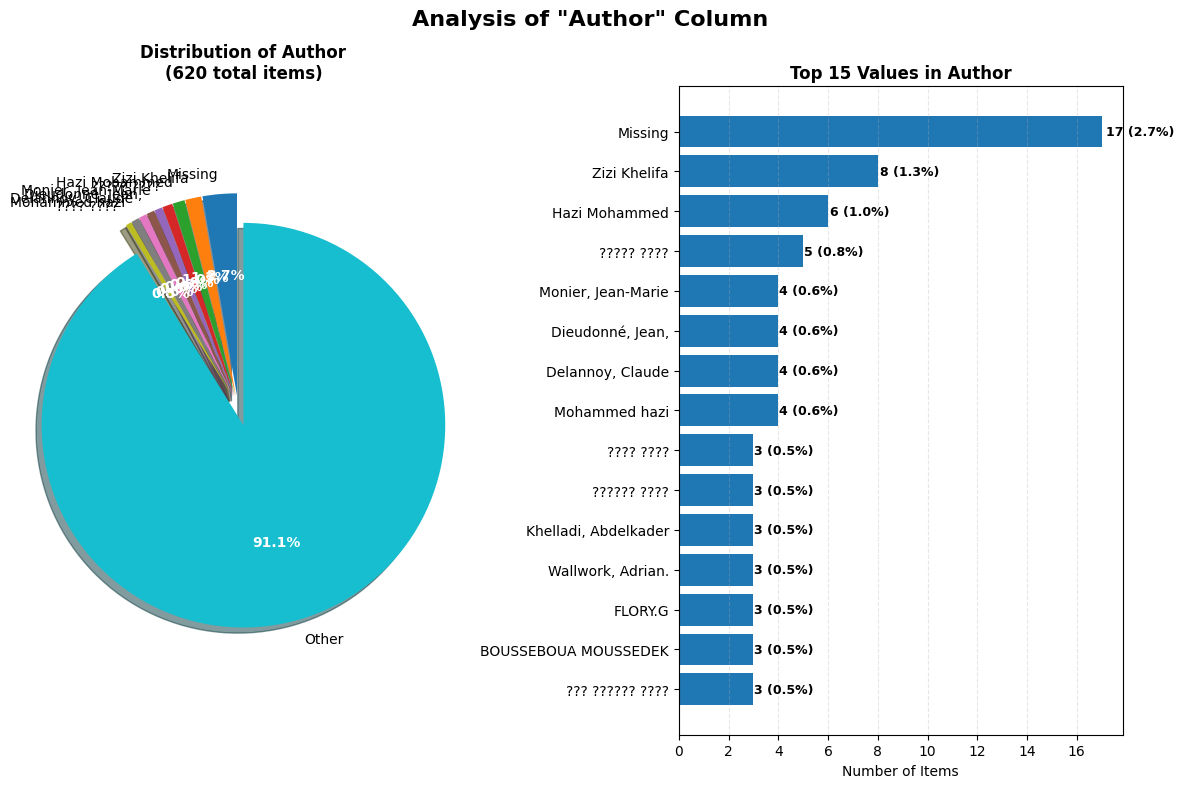

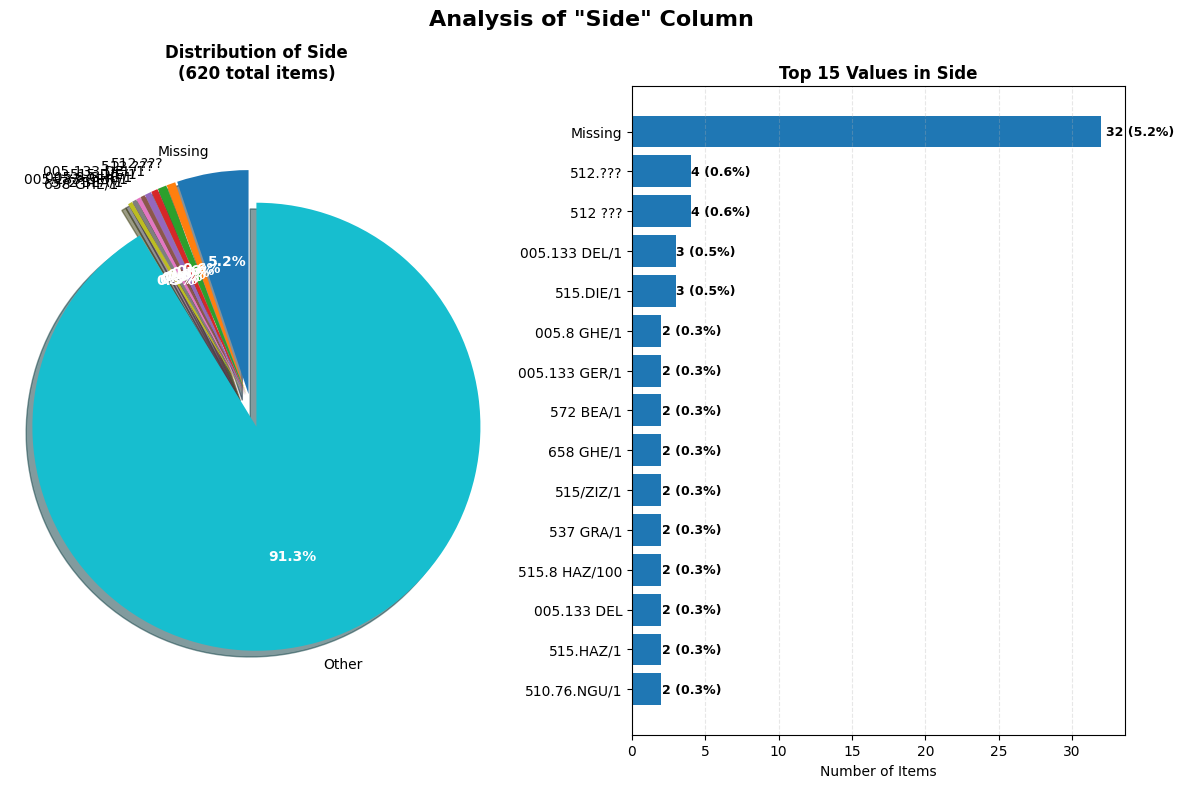

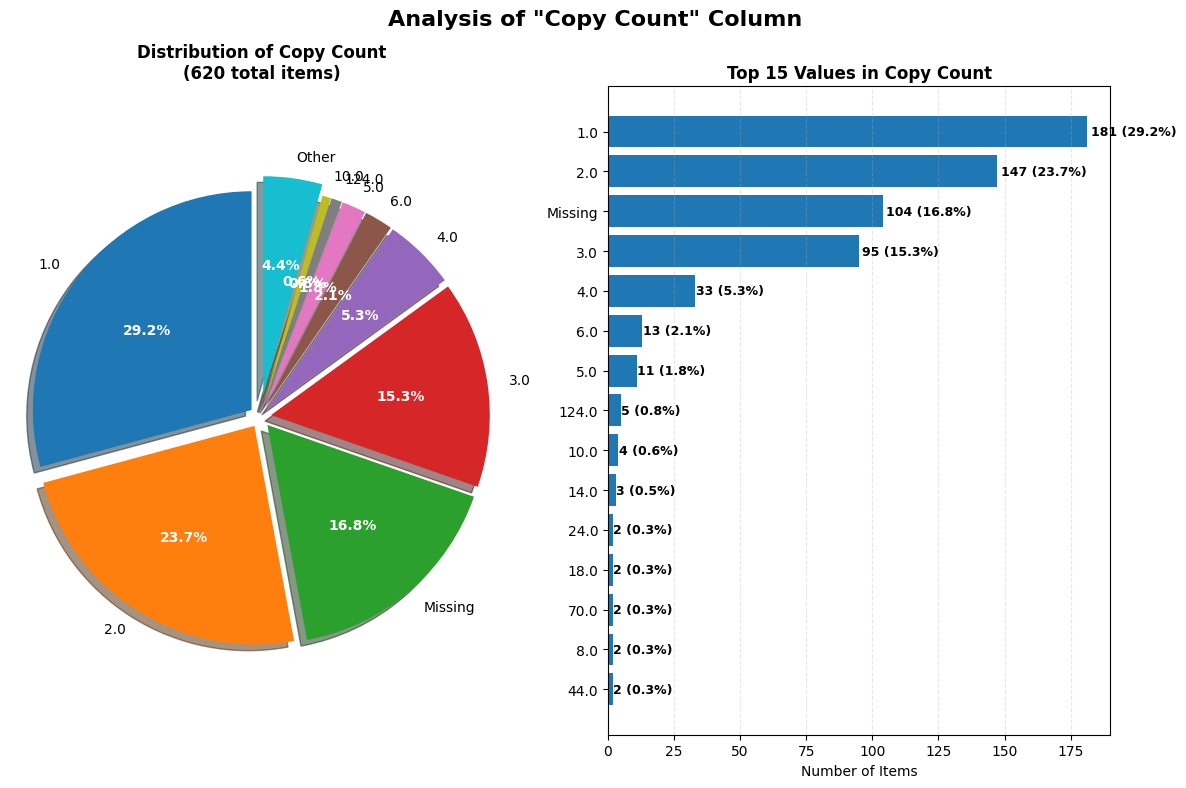

In [76]:
# Visualize unique value distributions for each column (except Title which has all unique values)
for column in raw_library_catalogue.columns:
    # Skip columns with all unique values
    if column in {'Inventory Number', 'Title'}:
        continue
    visualize_unique_values(raw_library_catalogue, column)

In [77]:
# Create working copy for preprocessing
# The "preproc_library_catalogue" dataframe will be the main axis of preprocessing
preproc_library_catalogue = raw_library_catalogue

In [78]:
# ============================================================================
# DATATYPE CASTING
# Convert columns to appropriate data types for analysis.
# ============================================================================

# Cast text columns to string type
preproc_library_catalogue['ISBN/ISSN'] = preproc_library_catalogue['ISBN/ISSN'].astype('string')
preproc_library_catalogue['Title'] = preproc_library_catalogue['Title'].astype('string')
preproc_library_catalogue['Author'] = preproc_library_catalogue['Author'].astype('string')

# Convert Copy Count to numeric (Int16 to save memory while handling missing values)
preproc_library_catalogue['Copy Count'] = pd.to_numeric(
    preproc_library_catalogue['Copy Count'], 
    errors='coerce'
).astype('Int16')

# Display updated data types
preproc_library_catalogue.dtypes

ISBN/ISSN     string[python]
Title         string[python]
Author        string[python]
Side                  object
Copy Count             Int16
dtype: object

## Preprocessing : Dropping Columns

In [79]:
# Drop "Side" column - physical library location is not relevant for our analysis
preproc_library_catalogue = preproc_library_catalogue.drop(['Side'], axis=1)
preproc_library_catalogue.head()

,ISBN/ISSN,Title,Author,Copy Count
0,978996101320,Calcul DIfferentiel et Integral Tome 01,"Piskounov,N",6
1,9782744070372,"Compilateurs : principes, techniques et outils...","Aho, Alfred",2
2,2729823212,"Bit après bit : numération, arithmétique binai...","Mercier, Jean-Jacques",1
3,274640432X,"Le Nouveau guide du PC : comprendre, acheter, ...","Steiner, Jack",1
4,2704200106,Introduction à l'informatique : cours et probl...,"Scheid, Francis",1


In [80]:
# Display missing value summary after dropping columns
MissingValueSummary(preproc_library_catalogue)

Number of instances = 620

Missing Values Summary:
    Column  Missing_Values Percent_Missing
 ISBN/ISSN              42           6.77%
     Title               0           0.00%
    Author              17           2.74%
Copy Count             104          16.77%


## EDA On Copy Count

### Value Analysis

In [81]:
# ============================================================================
# COPY COUNT VALUE ANALYSIS
# Examine the unique values in the Copy Count column.
# ============================================================================

# Count unique values
unique_count = preproc_library_catalogue['Copy Count'].nunique()
print(f"Number of unique values in 'Copy Count': {unique_count}")

# Display all unique values
unique_values = preproc_library_catalogue['Copy Count'].unique()
print(f"\nUnique values: {unique_values}")

Number of unique values in 'Copy Count': 27

Unique values: <IntegerArray>
[   6,    2,    1,    4,    3,   15,    5,   18,   44,   19,   24,   14, <NA>,
    8,   33,   12,  124,  153,   62,   73,    9,   10,   70,   54,  140,   30,
   35,    7]
Length: 28, dtype: Int16


### Normality Test

In [82]:
# Perform Kolmogorov-Smirnov test for normality
# Low p-value indicates data is NOT normally distributed
ks_stat, ks_p = stats.kstest(
    preproc_library_catalogue['Copy Count'].dropna(), 
    'norm', 
    args=(preproc_library_catalogue['Copy Count'].mean(), preproc_library_catalogue['Copy Count'].std())
)
print(f"K-S Test: p-value = {ks_p:.4f}")

K-S Test: p-value = 0.0000


### Distribution Visualisation

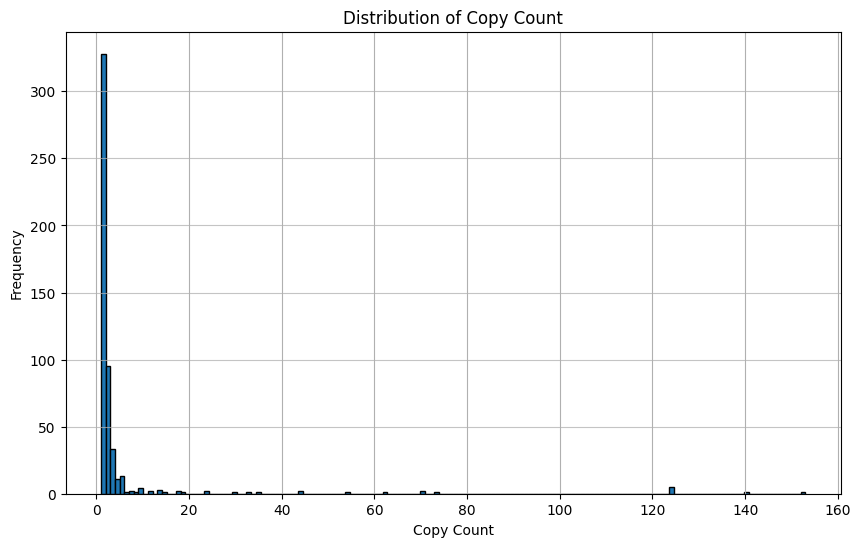

In [83]:
# Plot histogram of raw Copy Count values
plt.figure(figsize=(10, 6))
preproc_library_catalogue['Copy Count'].hist(bins=150, edgecolor='black')
plt.title('Distribution of Copy Count')
plt.xlabel('Copy Count')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

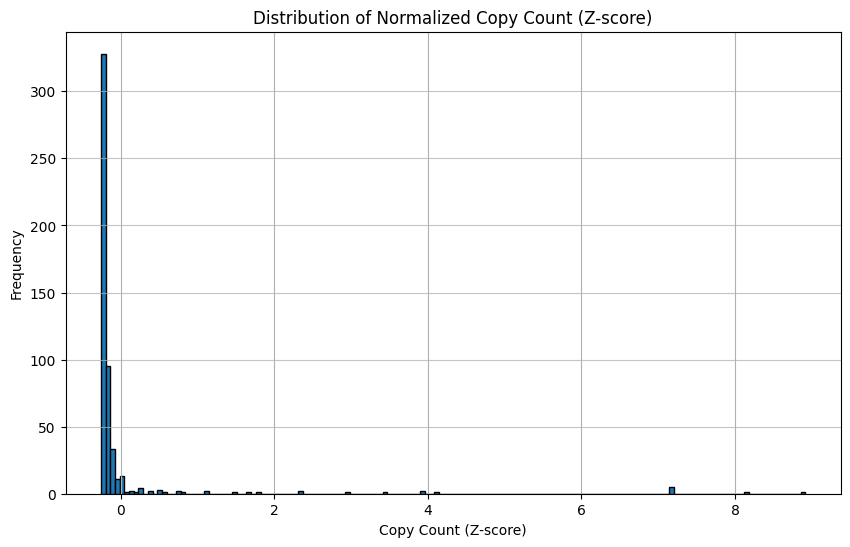

In [84]:
# Create and plot Z-score normalized Copy Count
mu = preproc_library_catalogue['Copy Count'].mean()
sigma = preproc_library_catalogue['Copy Count'].std()
normalized_copy_count = (preproc_library_catalogue['Copy Count'] - mu) / sigma

plt.figure(figsize=(10, 6))
normalized_copy_count.hist(bins=150, edgecolor='black')
plt.title('Distribution of Normalized Copy Count (Z-score)')
plt.xlabel('Copy Count (Z-score)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Verdict

As you can see, the distribution of frequency values of copy count is skewed to the right, this means we are allowed to replace missing values with the median

In [85]:
# ============================================================================
# MISSING VALUE IMPUTATION
# Replace missing Copy Count values with median (appropriate for right-skewed data).
# ============================================================================

# Calculate median (excluding NaN)
median_value = preproc_library_catalogue['Copy Count'].median()
print(f"Median of Copy Count: {median_value}")

# Replace NaN with median
preproc_library_catalogue['Copy Count'].fillna(median_value, inplace=True)

Median of Copy Count: 2.0


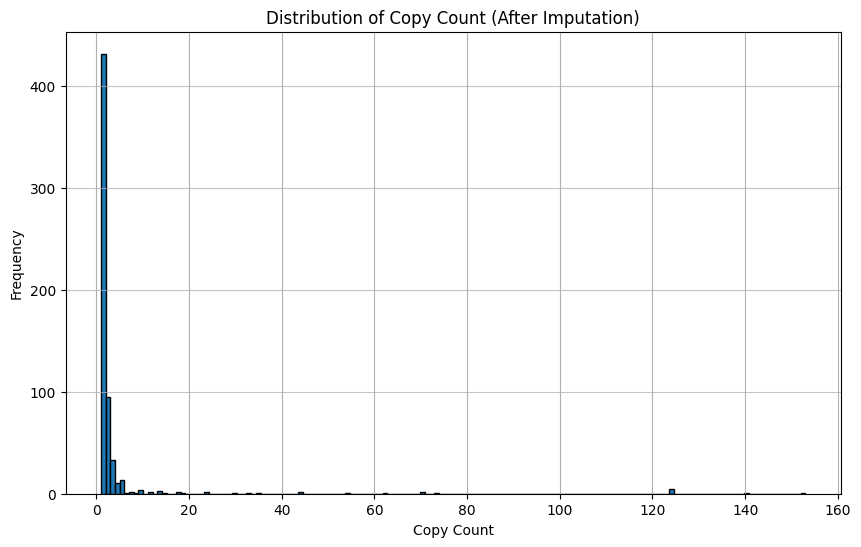

In [86]:
# Plot histogram after imputation to verify distribution is preserved
plt.figure(figsize=(10, 6))
preproc_library_catalogue['Copy Count'].hist(bins=150, edgecolor='black')
plt.title('Distribution of Copy Count (After Imputation)')
plt.xlabel('Copy Count')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [87]:
# Verify imputation and export for inspection
MissingValueSummary(preproc_library_catalogue)
TempCSVFile(preproc_library_catalogue)

Number of instances = 620

Missing Values Summary:
    Column  Missing_Values Percent_Missing
 ISBN/ISSN              42           6.77%
     Title               0           0.00%
    Author              17           2.74%
Copy Count               0           0.00%
Data exported to: C:\Users\fafao\AppData\Local\Temp\tmpphwvy79c.csv


Some rows have no ISBN/ISSN and question marks for authors and titles, we drop them:

In [88]:
# ============================================================================
# REMOVE PLACEHOLDER ENTRIES
# Drop rows containing '??' placeholders which indicate incomplete data.
# ============================================================================

# Identify placeholder entries containing '??'
placeholder_mask = (
    preproc_library_catalogue['Author'].str.contains('??', regex=False, na=False) |
    preproc_library_catalogue['Title'].str.contains('??', regex=False, na=False) |
    preproc_library_catalogue['ISBN/ISSN'].str.contains('??', regex=False, na=False)
)

placeholder_rows = preproc_library_catalogue[placeholder_mask]
print("=== Rows containing '??' placeholders ===")

if placeholder_rows.empty:
    print("No placeholder rows detected.")
else:
    print(f"Found {len(placeholder_rows)} rows. Showing up to 5 examples:")
    display(placeholder_rows.head())

    # Drop the rows and reset the index
    preproc_library_catalogue = preproc_library_catalogue[~placeholder_mask].reset_index(drop=True)
    print(f"\n✅ Removed {len(placeholder_rows)} placeholder rows.")

MissingValueSummary(preproc_library_catalogue)
TempCSVFile(preproc_library_catalogue)

=== Rows containing '??' placeholders ===
Found 37 rows. Showing up to 5 examples:


,ISBN/ISSN,Title,Author,Copy Count
27,9789957525880,Digital signal processing (with matlab) : ????...,Abu Jzar; Amjad abbas,1
160,9789961014905,?????? ?????? ??????? ??? ??????? ????????,"????, ????",2
162,978996101528,?????? ???????? ?????? ???????? ????? 01 : ???...,??? ?????? ????,1
163,978996101529,?????? ???????? ?????? ???????? ????? 02 : ???...,??? ?????? ????,1
166,9789961016268,???????? ??????? ? ?????? ????????,?????? ????,2



✅ Removed 37 placeholder rows.
Number of instances = 583

Missing Values Summary:
    Column  Missing_Values Percent_Missing
 ISBN/ISSN              25           4.29%
     Title               0           0.00%
    Author              11           1.89%
Copy Count               0           0.00%
Data exported to: C:\Users\fafao\AppData\Local\Temp\tmpqm0r7sig.csv


### Noramlizing Textual Format (Uppercase)

In [89]:
# ============================================================================
# TEXT NORMALIZATION
# Convert Title and Author columns to uppercase for consistency.
# ============================================================================

preproc_library_catalogue['Title'] = preproc_library_catalogue['Title'].str.upper()
preproc_library_catalogue['Author'] = preproc_library_catalogue['Author'].str.upper()

In [90]:
# ============================================================================
# ISBN ENRICHMENT
# Fetch missing ISBNs using Title and Author via external APIs.
# ============================================================================

print("🚀 Starting ISBN lookup for missing values...")
print("=" * 60)

# Before stats
original_missing = preproc_library_catalogue['ISBN/ISSN'].isna().sum()
print(f"BEFORE: {original_missing} missing ISBNs")

# Run ISBN lookup
enriched_df, processed_rows = fill_missing_isbns(preproc_library_catalogue)

# After stats
new_missing = enriched_df['ISBN/ISSN'].isna().sum()
print(f"\nAFTER: {new_missing} missing ISBNs")
print(f"ISBNs filled: {original_missing - new_missing}")

# Update dataframe
preproc_library_catalogue = enriched_df

# Save results to temporary file
temp_csv = tempfile.NamedTemporaryFile(mode='w', suffix='.csv', delete=False)
preproc_library_catalogue.to_csv(temp_csv.name, index=False)
temp_csv.close()
print(f"\n💾 Saved updated dataset to: {temp_csv.name}")

# Show sample of filled records
if not processed_rows.empty:
    filled_mask = (
        preproc_library_catalogue['ISBN/ISSN'].notna() & 
        preproc_library_catalogue.index.isin(processed_rows.index)
    )
    
    if filled_mask.any():
        print("\n📚 Sample of newly filled ISBNs:")
        sample = preproc_library_catalogue[filled_mask].head(3)
        for idx, row in sample.iterrows():
            print(f"\nRow {idx}:")
            print(f"  Title:  {row['Title'][:70]}...")
            print(f"  Author: {row['Author']}")
            print(f"  ISBN:   {row['ISBN/ISSN']}")
    else:
        print("\n⚠️ No ISBNs were found for the processed rows")
else:
    print("\n✅ No rows needed processing")

MissingValueSummary(preproc_library_catalogue)

🚀 Starting ISBN lookup for missing values...
BEFORE: 25 missing ISBNs
🔍 Found 22 rows with missing ISBN but having Title and Author
Processing row 107:
  Title:  NOTIONS SUR LE CALCUL DES PROBABILITÉS,C CORRIGÉS...
  Author: CHIBAT, AHMED...
  ✅ Found ISBN: 9973311604
Processing row 303:
  Title:  LECTURES ON BOOLEN ALGEBRAS...
  Author: R.HALMOS.PAUL...
  ✅ Found ISBN: 9781461298557
Processing row 328:
  Title:  STRUCTURES ALGEBRIQUES : MATHÉMATIQUES...
  Author: LANG SERGE...
  ❌ No ISBN found
Processing row 345:
  Title:  INTELLIGENCE ARTIFICIELLE...
  Author: EDITH SCHOMBERG...
  ❌ No ISBN found
Processing row 350:
  Title:  ÉLÉMENT D'ANALYSE...
  Author: ALLAB, KADA...
  ✅ Found ISBN: 2729876561
Progress: 5/22
Processing row 354:
  Title:  COURS ÉLÉMENTAIRE DE TOPOGRAPHIE...
  Author: B DUBUISSON...
  ❌ No ISBN found
Processing row 370:
  Title:  INTELLIGENCE ARTIFICIELLE RÉSOLUTION DES PROBLÈMES...
  Author: LOUIS LAURIERE JEAN...
  ❌ No ISBN found
Processing row 391:
  Title:  E

In [91]:
# ============================================================================
# MANUAL DATA CLEANING
# Remove books with very limited information and manually assign known ISBNs.
# ============================================================================

# Drop books with insufficient information for identification
bad_books = {
    'INTRODUCTION TO WEB',
    'TOPOLOGIE ÉLÉMENTAIRE : GÉOMÉTRIE DES FONCTIONS DE SEGMENTS,DE COURBES ,DE CERCLES ET DE DISQUES',
    'PROBABILITES ET STATISTIQUE MATHEMATIQUE',
    'EECTRONIQUE NUMERIQUE TOME 2: ACQUISITION ,CONVERSION ET RES'
}

for book in bad_books:
    preproc_library_catalogue = preproc_library_catalogue[preproc_library_catalogue['Title'] != book]

# Handle books with no ISBN that we can identify
unknown_books = {
    'EQUATIONS DIFFERENTIELLES (M108)',
    'ANTELLIGENCE ARTIFICIELLE PROBLÉME ET MÉTHODES',
    'STRUCTURES ALGEBRIQUES : MATHÉMATIQUES',
    'ELÉMENT DE TOPOGRAPHIE',
    'EECTRONIQUE NUMERIQUE TOME 2: ACQUISITION ,CONVERSION ET RESTITUTION DE DONNÉES'
}

for title in unknown_books:
    preproc_library_catalogue = preproc_library_catalogue[preproc_library_catalogue['Title'] != title]

preproc_library_catalogue = preproc_library_catalogue[preproc_library_catalogue['Author'] != 'CLAUDEL.J']

# Manually assign known ISBNs to identified books
isbn_title = {
    '2729601597': 'STRUCTURES ALGEBRIQUES',
    '047190581X': 'INTELLIGENCE ARTIFICIELLE',
    '221202102X': 'COURS ÉLÉMENTAIRE DE TOPOGRAPHIE',
    '2212081901': 'INTELLIGENCE ARTIFICIELLE RÉSOLUTION DES PROBLÈMES',
    '9782212021226': 'COURS DE CALCULS TOPOMÉTRIQUES',
    '2212083246': 'SYSTEMES EXPERTS : ORGANISATION ET PROGRAMMATION DES BASES DE CONNAISSANCE EN CACUL PROSITIONNEL' 
}

for isbn, title in isbn_title.items():
    preproc_library_catalogue.loc[preproc_library_catalogue['Title'] == title, 'ISBN/ISSN'] = isbn

MissingValueSummary(preproc_library_catalogue)
TempCSVFile(preproc_library_catalogue)

Number of instances = 566

Missing Values Summary:
    Column  Missing_Values Percent_Missing
 ISBN/ISSN               1           0.18%
     Title               0           0.00%
    Author               0           0.00%
Copy Count               0           0.00%
Data exported to: C:\Users\fafao\AppData\Local\Temp\tmprp7tniss.csv


We manually handle the 4 rows with no ISBN/ISSN:

In [92]:
# Drop specific problematic row that cannot be recovered
preproc_library_catalogue = preproc_library_catalogue.drop(index=359)

MissingValueSummary(preproc_library_catalogue)
TempCSVFile(preproc_library_catalogue)

Number of instances = 565

Missing Values Summary:
    Column  Missing_Values Percent_Missing
 ISBN/ISSN               1           0.18%
     Title               0           0.00%
    Author               0           0.00%
Copy Count               0           0.00%
Data exported to: C:\Users\fafao\AppData\Local\Temp\tmpxm8q_ewn.csv


In [93]:
# ============================================================================
# TITLE AND AUTHOR ENRICHMENT
# Update titles and authors using ISBN-based API lookups.
# ============================================================================

print("🚀 UPDATING ALL TITLES AND AUTHORS USING ISBN")
print("=" * 60)

# Before stats
print("BEFORE UPDATE:")
print(f"Rows with missing Title: {preproc_library_catalogue['Title'].isna().sum()}")
print(f"Rows with missing Author: {preproc_library_catalogue['Author'].isna().sum()}")
print(f"Rows with missing Copy Count: {preproc_library_catalogue['Copy Count'].isna().sum()}")
print(f"Rows with missing ISBN/ISSN: {preproc_library_catalogue['ISBN/ISSN'].isna().sum()}")

# Run update
updated_df = update_all_titles_authors(preproc_library_catalogue)

# After stats
print("\nAFTER UPDATE:")
print(f"Rows with missing Title: {updated_df['Title'].isna().sum()}")
print(f"Rows with missing Author: {updated_df['Author'].isna().sum()}")

# Update main dataframe
preproc_library_catalogue = updated_df

🚀 UPDATING ALL TITLES AND AUTHORS USING ISBN
BEFORE UPDATE:
Rows with missing Title: 0
Rows with missing Author: 0
Rows with missing Copy Count: 0
Rows with missing ISBN/ISSN: 1
📚 Processing 565 rows...
Processed 10/565 rows...
Processed 20/565 rows...
Processed 30/565 rows...
Processed 40/565 rows...
Processed 50/565 rows...
Processed 60/565 rows...
Processed 70/565 rows...
Processed 80/565 rows...
Processed 90/565 rows...
Processed 100/565 rows...
Processed 110/565 rows...
Processed 120/565 rows...
Processed 130/565 rows...
Processed 140/565 rows...
Processed 150/565 rows...
Processed 160/565 rows...
Processed 170/565 rows...
Processed 180/565 rows...
Processed 190/565 rows...
Processed 200/565 rows...
Processed 210/565 rows...
Processed 220/565 rows...
Processed 230/565 rows...
Processed 240/565 rows...
Processed 250/565 rows...
Processed 260/565 rows...
Processed 270/565 rows...
Processed 280/565 rows...
Processed 290/565 rows...
Processed 300/565 rows...
Processed 310/565 rows...


In [94]:
# Display current state and identify rows still missing Author
MissingValueSummary(preproc_library_catalogue)
TempCSVFile(preproc_library_catalogue)

# Show rows with missing Author information
no_isbn_rows = preproc_library_catalogue[preproc_library_catalogue['Author'].isna()]
no_isbn_rows

Number of instances = 565

Missing Values Summary:
    Column  Missing_Values Percent_Missing
 ISBN/ISSN               1           0.18%
     Title               0           0.00%
    Author               0           0.00%
Copy Count               0           0.00%
Data exported to: C:\Users\fafao\AppData\Local\Temp\tmpa_3kv6g2.csv


,ISBN/ISSN,Title,Author,Copy Count


In [108]:
# Export to specific path
file_path = r"../../data/processed/library_catalogue.csv"  # Windows

preproc_library_catalogue.to_csv(file_path, index=False, encoding='utf-8')
print(f"Data exported to: {file_path}")

Data exported to: ../../data/processed/library_catalogue.csv


## Sorting Rows Alphabetically Based On Title

In [2]:
# Read the CSV file
df = pd.read_csv('../../data/processed/library_catalogue.csv')

# Sort by 'Title' column
df = df.sort_values('Title')

# Save back to the same file
df.to_csv('../../data/processed/library_catalogue.csv', index=False)